In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/content/drive/MyDrive/AI ML/Basic and safely managed sanitation services.csv")

print(data.head())

                                           Indicator PUBLISH STATES  Year  \
0  Population using safely managed sanitation ser...      Published  2000   
1  Population using safely managed sanitation ser...      Published  2000   
2  Population using safely managed sanitation ser...      Published  2000   
3  Population using safely managed sanitation ser...      Published  2001   
4  Population using safely managed sanitation ser...      Published  2001   

  WHO region  Country Residence Area Type  Display Value   Numeric  Low  High  \
0     Europe  Albania               Rural             38  37.75931  NaN   NaN   
1     Europe  Albania               Total             39  38.61018  NaN   NaN   
2     Europe  Albania               Urban             40  39.79776  NaN   NaN   
3     Europe  Albania               Rural             37  37.43953  NaN   NaN   
4     Europe  Albania               Total             38  38.42525  NaN   NaN   

   Comments  
0       NaN  
1       NaN  
2       

Understand Dataset Structure

In [3]:
#check dataset information.
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13023 entries, 0 to 13022
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Indicator            13023 non-null  object 
 1   PUBLISH STATES       13023 non-null  object 
 2   Year                 13023 non-null  int64  
 3   WHO region           13023 non-null  object 
 4   Country              13023 non-null  object 
 5   Residence Area Type  13023 non-null  object 
 6   Display Value        13023 non-null  int64  
 7   Numeric              13023 non-null  float64
 8   Low                  0 non-null      float64
 9   High                 0 non-null      float64
 10  Comments             0 non-null      float64
dtypes: float64(4), int64(2), object(5)
memory usage: 1.1+ MB
None


In [4]:
#check column names
print(data.columns)

Index(['Indicator', 'PUBLISH STATES', 'Year', 'WHO region', 'Country',
       'Residence Area Type', 'Display Value', 'Numeric', 'Low', 'High',
       'Comments'],
      dtype='object')


In [5]:
#Check summary statistics
print(data.describe())

               Year  Display Value       Numeric  Low  High  Comments
count  13023.000000   13023.000000  13023.000000  0.0   0.0       0.0
mean    2008.551716      66.846886     66.844673  NaN   NaN       NaN
std        5.169474      31.296505     31.294890  NaN   NaN       NaN
min     2000.000000       1.000000      0.959460  NaN   NaN       NaN
25%     2004.000000      39.000000     39.106445  NaN   NaN       NaN
50%     2009.000000      79.000000     78.514950  NaN   NaN       NaN
75%     2013.000000      95.000000     95.489180  NaN   NaN       NaN
max     2017.000000     100.000000    100.000010  NaN   NaN       NaN


In [6]:
#Check summary statistics
print(data.isnull().sum())

Indicator                  0
PUBLISH STATES             0
Year                       0
WHO region                 0
Country                    0
Residence Area Type        0
Display Value              0
Numeric                    0
Low                    13023
High                   13023
Comments               13023
dtype: int64


In [14]:
#If missing values exist, drop columns with all missing values
data = data.drop(columns=['Low', 'High', 'Comments'], errors='ignore')

In [9]:
#Data Transformation
#selecting useful columns
data = data[['Country','Year','Numeric']]

In [10]:
#Convert data type if needed:
data['Year'] = data['Year'].astype(int)

In [16]:
data = pd.read_csv("/content/drive/MyDrive/AI ML/Basic and safely managed sanitation services.csv")

print(data.head())

                                           Indicator PUBLISH STATES  Year  \
0  Population using safely managed sanitation ser...      Published  2000   
1  Population using safely managed sanitation ser...      Published  2000   
2  Population using safely managed sanitation ser...      Published  2000   
3  Population using safely managed sanitation ser...      Published  2001   
4  Population using safely managed sanitation ser...      Published  2001   

  WHO region  Country Residence Area Type  Display Value   Numeric  Low  High  \
0     Europe  Albania               Rural             38  37.75931  NaN   NaN   
1     Europe  Albania               Total             39  38.61018  NaN   NaN   
2     Europe  Albania               Urban             40  39.79776  NaN   NaN   
3     Europe  Albania               Rural             37  37.43953  NaN   NaN   
4     Europe  Albania               Total             38  38.42525  NaN   NaN   

   Comments  
0       NaN  
1       NaN  
2       

In [17]:
#If missing values exist, drop columns with all missing values
data = data.drop(columns=['Low', 'High', 'Comments'], errors='ignore')

In [18]:
#Data Transformation
#selecting useful columns
data = data[['Country','Year','Numeric']]

In [19]:
#Convert data type if needed:
data['Year'] = data['Year'].astype(int)

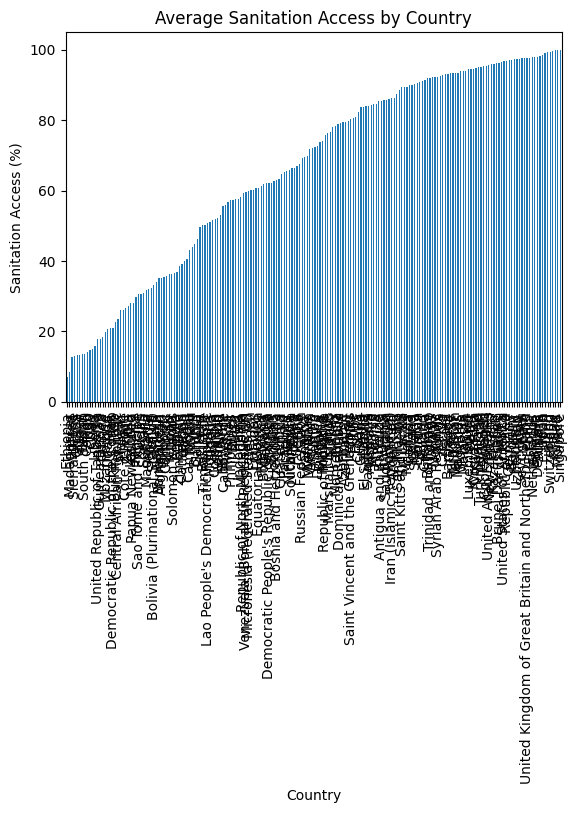

In [21]:
#Data Visualization (Exploration)
#Sanitation Access by Country
data.groupby("Country")["Numeric"].mean().sort_values().plot(kind="bar")

plt.title("Average Sanitation Access by Country")
plt.xlabel("Country")
plt.ylabel("Sanitation Access (%)")
plt.show()

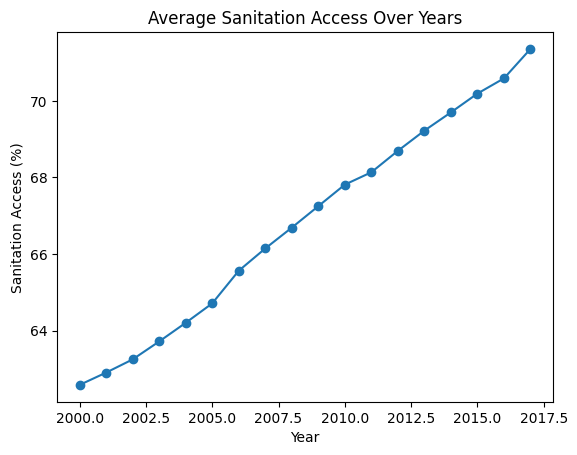

In [22]:
# Sanitation Trend Over Years

data.groupby("Year")["Numeric"].mean().plot(kind="line", marker="o")

plt.title("Average Sanitation Access Over Years")
plt.xlabel("Year")
plt.ylabel("Sanitation Access (%)")
plt.show()

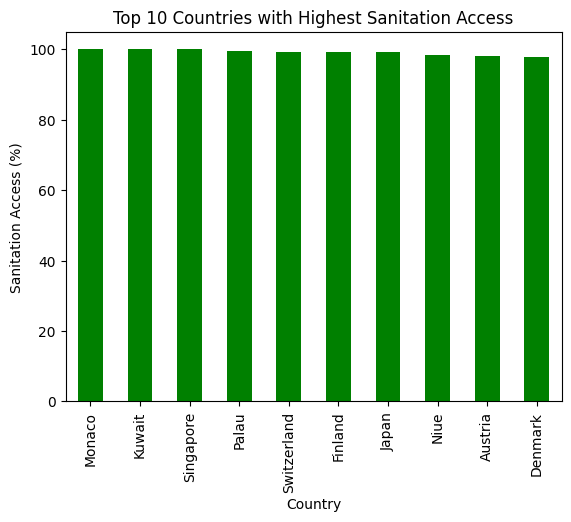

In [23]:
# Top 10 Countries

top10 = data.groupby("Country")["Numeric"].mean().sort_values(ascending=False).head(10)

top10.plot(kind="bar", color="green")

plt.title("Top 10 Countries with Highest Sanitation Access")
plt.xlabel("Country")
plt.ylabel("Sanitation Access (%)")
plt.show()

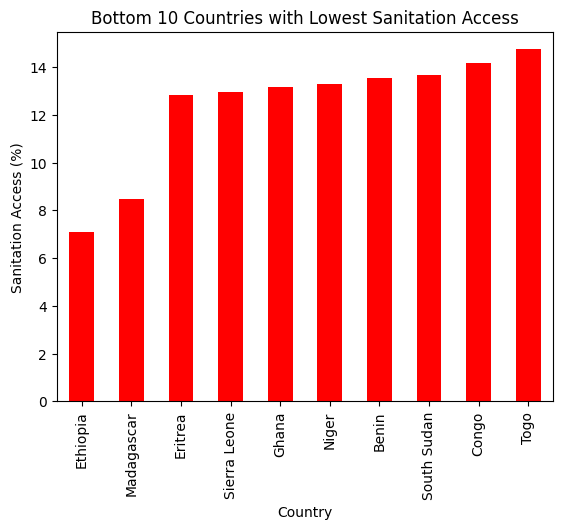

In [24]:
# Bottom 10 Countries

bottom10 = data.groupby("Country")["Numeric"].mean().sort_values().head(10)

bottom10.plot(kind="bar", color="red")

plt.title("Bottom 10 Countries with Lowest Sanitation Access")
plt.xlabel("Country")
plt.ylabel("Sanitation Access (%)")
plt.show()

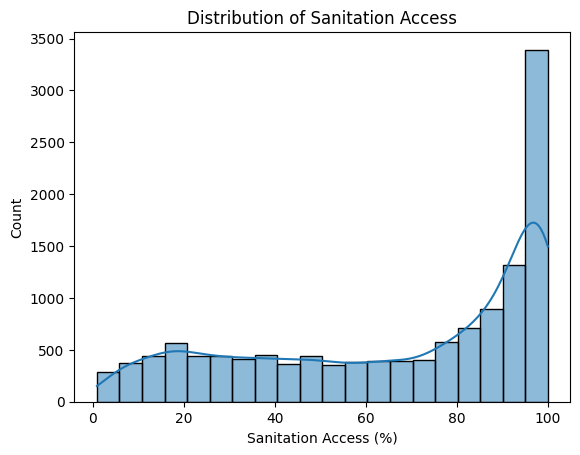

In [25]:
# Distribution Plot

import seaborn as sns

sns.histplot(data["Numeric"], bins=20, kde=True)

plt.title("Distribution of Sanitation Access")
plt.xlabel("Sanitation Access (%)")
plt.show()

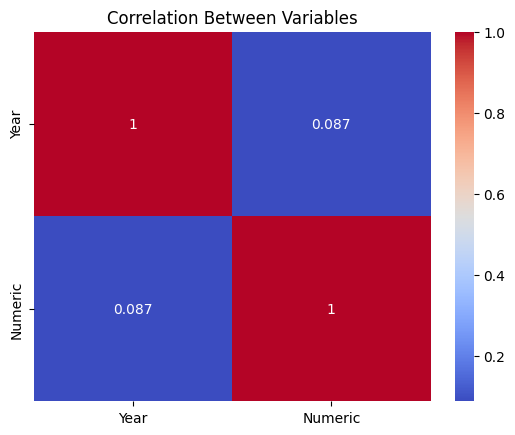

In [27]:
# Correlation Heatmap

sns.heatmap(data.drop(columns=['Country']).corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Between Variables")
plt.show()

In [28]:
#model training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Selecting features
X = data[["Year"]]
y = data["Numeric"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()

model.fit(X_train, y_train)

# Prediction
prediction = model.predict(X_test)

print(prediction)

[64.80957235 63.32018472 62.32725964 ... 65.30603489 65.80249743
 69.77419775]


In [ ]:
data.to_csv("cleaned_sanitation_data.csv", index=False)

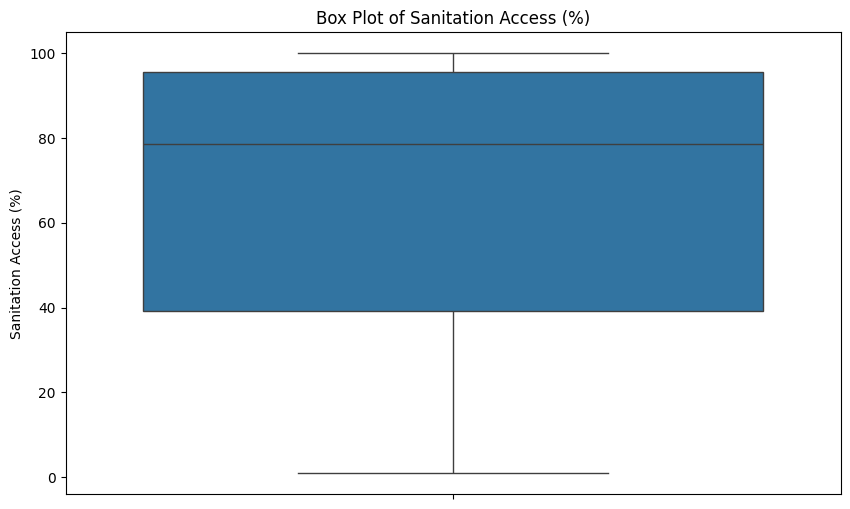

In [29]:
# Box Plot of Sanitation Access

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(y=data["Numeric"])
plt.title("Box Plot of Sanitation Access (%)")
plt.ylabel("Sanitation Access (%)")
plt.show()